## Unique analysis

### 1) Climate Analysis

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
filepath = "../data/GlobalWeatherRepository.csv"

In [25]:
df = pd.read_csv(filepath)
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [26]:
df["country"].value_counts().head(10)

country
Bulgaria      1941
Indonesia     1692
Thailand      1689
Turkey        1685
Sudan         1685
Bolivia       1678
Iran          1645
Belgium       1594
Madagascar    1303
Vietnam       1299
Name: count, dtype: int64

In [27]:
df['last_updated'] = pd.to_datetime(df['last_updated'])
df = df.set_index('last_updated').sort_index()

df['hour'] = df.index.hour
df['day'] = df.index.day
df['month'] = df.index.month
df['dayofweek'] = df.index.dayofweek
df['year'] = df.index.year

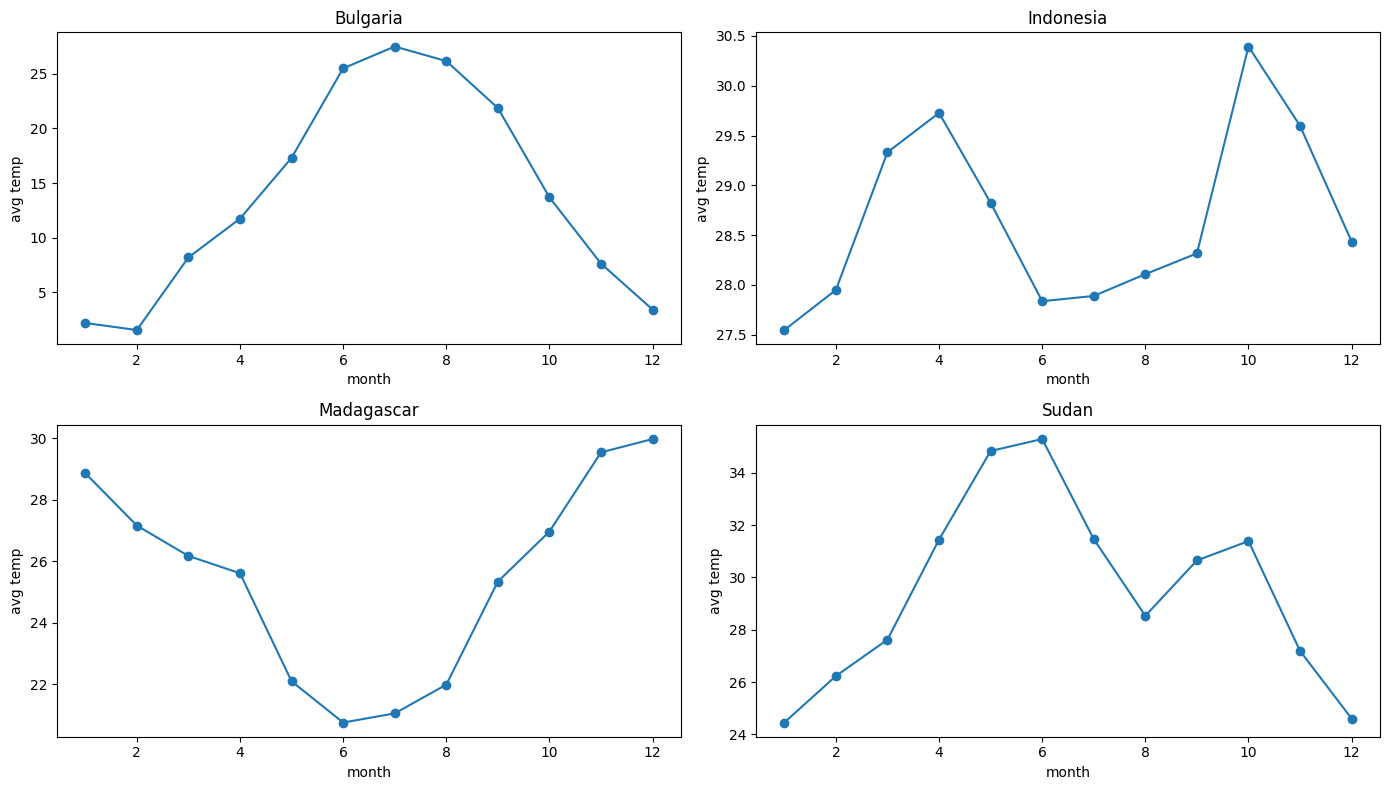

In [28]:
countries = ["Bulgaria", "Indonesia", "Madagascar", "Sudan"]
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)
axes = axes.flatten()

for i, country in enumerate(countries):
    monthly_avg = df[df["country"] == country].groupby("month")["temperature_celsius"].mean()
    axes[i].plot(monthly_avg.index, monthly_avg.values, marker="o")
    axes[i].set_title(country)
    axes[i].set_xlabel("month")
    axes[i].set_ylabel("avg temp")

plt.tight_layout()
plt.show()

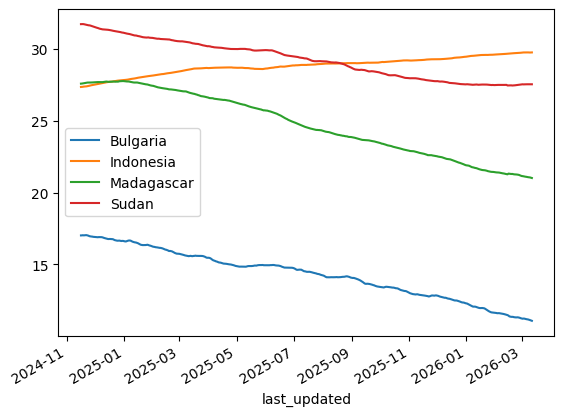

In [29]:
from statsmodels.tsa.seasonal import seasonal_decompose

for country in countries:
    series = df[df['country'] == country]['temperature_celsius'].resample('D').mean().dropna()
    decomp = seasonal_decompose(series, model='additive', period=365)
    decomp.trend.plot(label=country)

plt.legend()
plt.show()

In [30]:
country_stats = df.groupby('country').agg(
    avg_temp=('temperature_celsius', 'mean'),
    temp_range=('temperature_celsius', lambda x: x.max() - x.min()),
    avg_precip=('precip_mm', 'mean'),
    avg_humidity=('humidity', 'mean')
).sort_values('avg_temp')

country_stats

,avg_temp,temp_range,avg_precip,avg_humidity
country,,,,
Iceland,5.750890,43.5,0.164520,79.780546
Mongolia,5.900118,64.1,0.045735,50.315166
Canada,6.494543,54.2,0.192135,82.664294
Norway,8.434518,45.8,0.095390,77.050459
Andorra,9.070769,43.3,0.106876,65.489941
...,...,...,...,...
Qatar,32.913642,31.1,0.002894,40.213523
Турция,34.000000,0.0,0.000000,44.000000
Turkménistan,37.800000,0.0,0.000000,11.000000


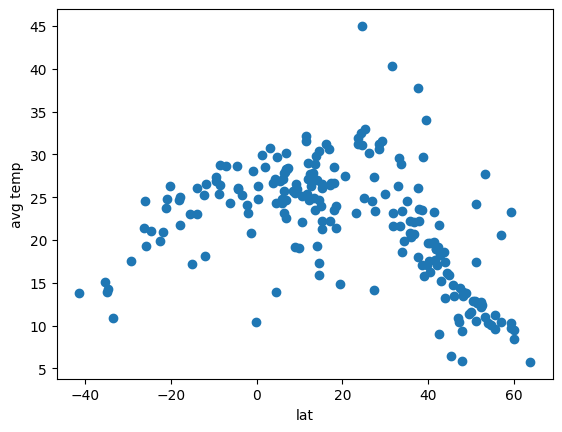

In [31]:
avg_by_country = df.groupby('country').agg(
    avg_lat=('latitude', 'mean'),
    avg_temp=('temperature_celsius', 'mean')
)

plt.scatter(avg_by_country["avg_lat"], avg_by_country["avg_temp"])
plt.xlabel("lat")
plt.ylabel("avg temp")
plt.show()

### 2) Environmental impact

In [32]:
df.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'temperature_celsius', 'temperature_fahrenheit',
       'condition_text', 'wind_mph', 'wind_kph', 'wind_degree',
       'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm',
       'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination',
       'hour', 'day', 'month', 'dayofweek', 'year'],
      dtype='object')

In [33]:
drop_cols = [
    "location_name",
    "timezone",
    "last_updated_epoch",
    "temperature_fahrenheit",
    "wind_mph",
    "wind_direction",
    "pressure_in",
    "precip_in",
    "feels_like_fahrenheit",
    "visibility_miles",
    "gust_mph",
    "sunrise",
    "sunset",
    "moonrise",
    "moonset",
    "moon_phase",
    "moon_illumination",
]

df.drop(columns=drop_cols, inplace=True)
df.columns

Index(['country', 'latitude', 'longitude', 'temperature_celsius',
       'condition_text', 'wind_kph', 'wind_degree', 'pressure_mb', 'precip_mm',
       'humidity', 'cloud', 'feels_like_celsius', 'visibility_km', 'uv_index',
       'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
       'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index',
       'air_quality_gb-defra-index', 'hour', 'day', 'month', 'dayofweek',
       'year'],
      dtype='object')

In [34]:
air_qual_cols = [
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide',
    'air_quality_us-epa-index',
    'air_quality_PM10'
]

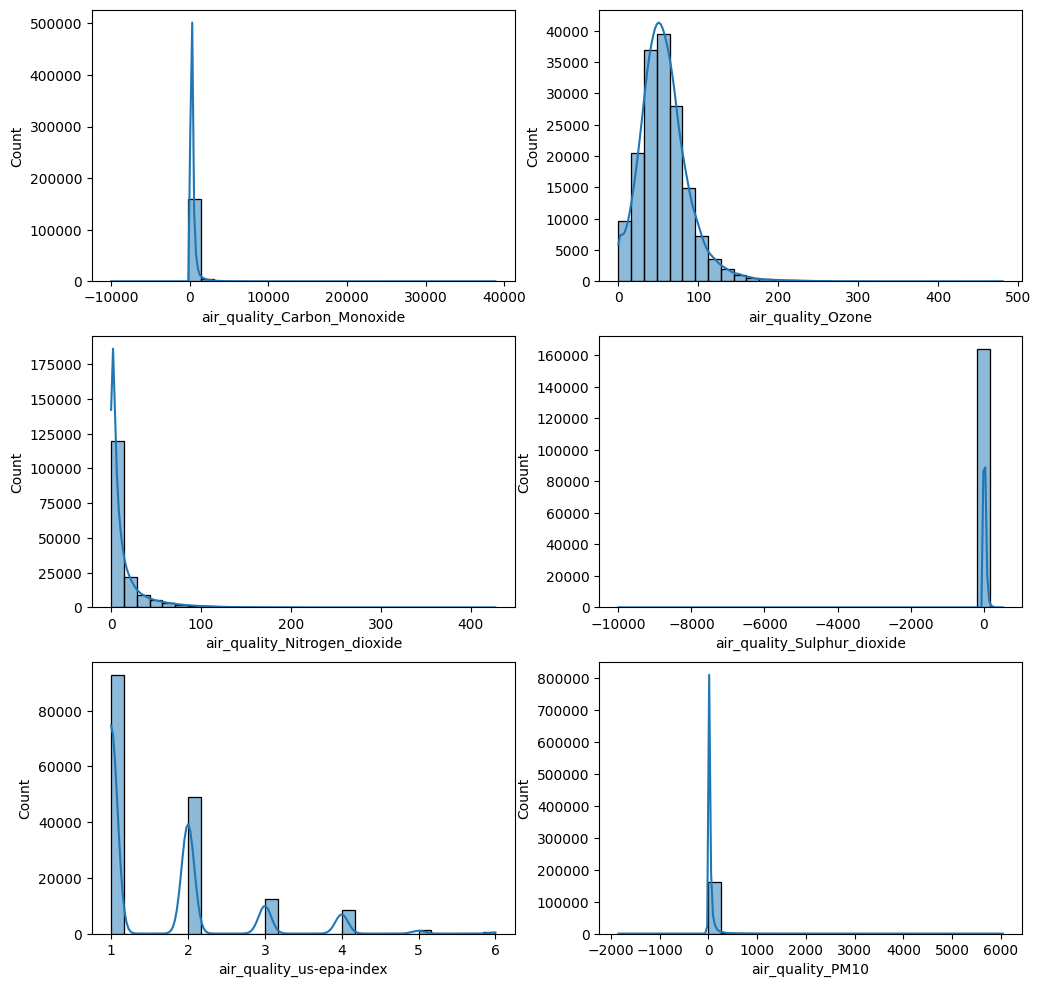

In [35]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, air_col in enumerate(air_qual_cols):
    sns.histplot(df[air_col], kde=True, bins=30, ax=axes[i])



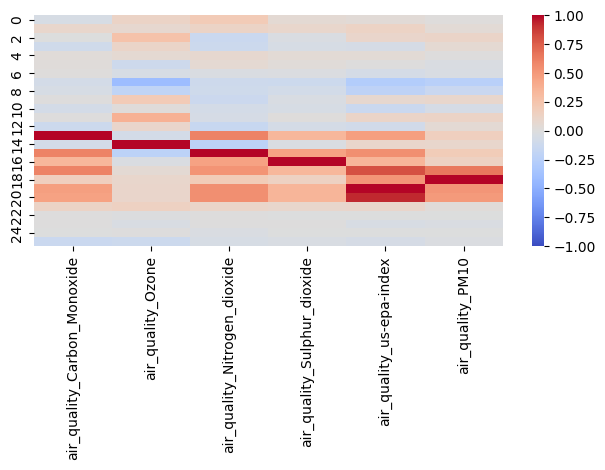

0) latitude
1) longitude
2) temperature_celsius
3) wind_kph
4) wind_degree
5) pressure_mb
6) precip_mm
7) humidity
8) cloud
9) feels_like_celsius
10) visibility_km
11) uv_index
12) gust_kph
13) air_quality_Carbon_Monoxide
14) air_quality_Ozone
15) air_quality_Nitrogen_dioxide
16) air_quality_Sulphur_dioxide
17) air_quality_PM2.5
18) air_quality_PM10
19) air_quality_us-epa-index
20) air_quality_gb-defra-index
21) hour
22) day
23) month
24) dayofweek
25) year


In [36]:
correlations = df.corr(numeric_only=True)[air_qual_cols]

correlations_num = correlations.copy()
correlations_num.index = range(len(correlations_num))

sns.heatmap(
    correlations_num,
    annot=False,
    cmap='coolwarm',
    vmin=-1, vmax=1,
)
plt.tight_layout()
plt.show()

for i, name in enumerate(correlations.index):
    print(f"{i}) {name}")

### Strong correllations:
 - Air quality ozone - temperature, humidity (neg), cloud(neg), uv_index
### Weaker:
 - Us epa index - humidity (neg), cloud(neg)
 - Quality PM10 - humidity (neg), cloud(neg)


## 3) Feature importance

In [37]:
# correllation coeff (only linear dependencies)
temp_corr = df.corr(numeric_only=True)["temperature_celsius"].sort_values(ascending=False)
temp_corr

temperature_celsius             1.000000
feels_like_celsius              0.978485
uv_index                        0.478353
air_quality_Ozone               0.259835
hour                            0.199123
longitude                       0.154667
air_quality_PM10                0.116405
visibility_km                   0.100841
air_quality_gb-defra-index      0.099890
wind_kph                        0.098813
air_quality_us-epa-index        0.097437
month                           0.088772
gust_kph                        0.081514
air_quality_PM2.5               0.066176
precip_mm                       0.031657
day                             0.005398
dayofweek                      -0.002281
air_quality_Carbon_Monoxide    -0.007548
wind_degree                    -0.014329
air_quality_Sulphur_dioxide    -0.029249
cloud                          -0.116852
air_quality_Nitrogen_dioxide   -0.134761
year                           -0.148432
pressure_mb                    -0.295848
humidity        

In [38]:
ind_features = [
    'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14',
    'rolling_mean_7', 'rolling_std_7',
    'month', 'dayofyear'
]

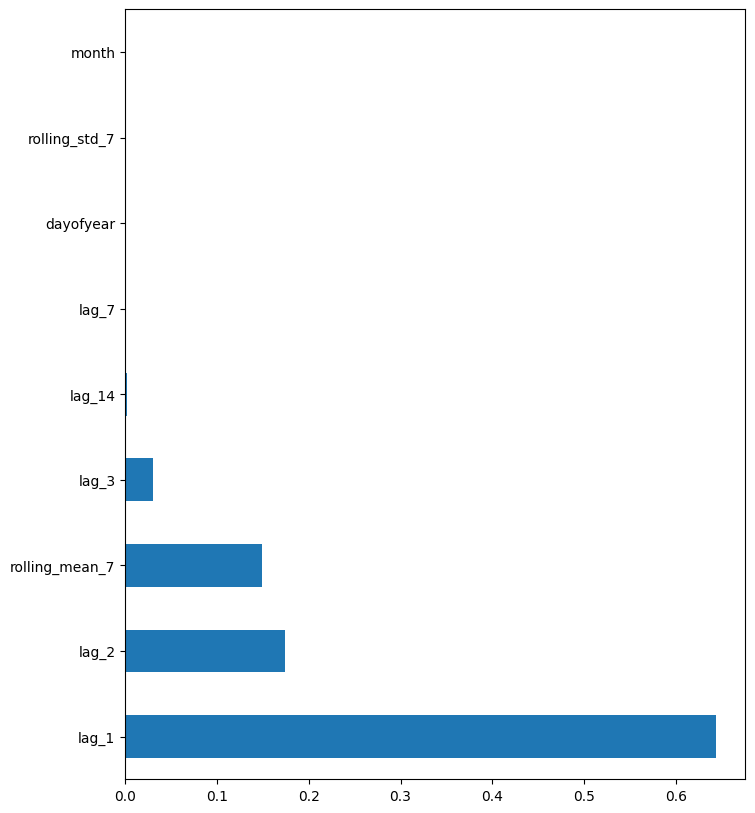

In [39]:
# feature importances from rf forecasting model (MDI)
import joblib
model_path = "../models/model.pkl"

model = joblib.load(model_path)

importances = pd.Series(model.feature_importances_, index=ind_features).sort_values(ascending=False)
importances.plot(kind='barh', figsize=(8,10))
plt.show()
